# Factor extensions — varimax, hierarchical, bucket-residual, joint rate-vol

Implementation framework for the four research tracks in the README.
Each track is one section: helpers live in `factors.py`, this notebook
wires them up against the mock pkls. All four tracks end in one
shared comparison table at the bottom.

When the company script swaps real pkls into `data/mock/`, the code
below runs unchanged.

## 0. Setup

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pca import load_long, to_wide, run_pca, reconstruct, EXPIRY_LABELS, TENOR_LABELS
from factors import (
    varimax, rotate_scores,
    hierarchical_pca, reconstruct_hierarchical,
    default_buckets, bucket_factors, regress_out,
    bucket_residual_pca, reconstruct_bucket_residual,
    cross_surface_cca, lagged_corr,
    variance_retained, loading_sparsity, rolling_stability,
    replication_residual, metrics_table,
)

sns.set_theme(style="whitegrid")

rate = to_wide(load_long("../data/mock/rate.pkl"))
vol  = to_wide(load_long("../data/mock/atm_vol.pkl"))
print("rate:", rate.shape, "  vol:", vol.shape)

def loading_grid(loadings, pc):
    return loadings.loc[pc].unstack("tenor").reindex(
        index=[e for e in EXPIRY_LABELS if e in loadings.columns.get_level_values("expiry")],
        columns=[t for t in TENOR_LABELS if t in loadings.columns.get_level_values("tenor")],
    )

def plot_loadings(loadings, pcs, title_prefix):
    fig, axes = plt.subplots(1, len(pcs), figsize=(6 * len(pcs), 5))
    if len(pcs) == 1:
        axes = [axes]
    for ax, pc in zip(axes, pcs):
        g = loading_grid(loadings, pc)
        vmax = float(g.abs().max().max())
        sns.heatmap(g, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                    cbar_kws={"label": "loading"})
        ax.set_title(f"{title_prefix} {pc}")
        ax.set_xlabel("Tenor"); ax.set_ylabel("Expiry")
    plt.tight_layout(); plt.show()

# vanilla baseline used by tracks 1, 4, and the comparison table
s_van, l_van, e_van = run_pca(rate, n_components=5)
print("vanilla rate explained:", e_van.round(3).tolist())

rate: (500, 204)   vol: (500, 204)


vanilla rate explained: [0.865, 0.002, 0.002, 0.002, 0.002]


## 1. Varimax-rotated PCA

Rotate the vanilla loadings so each factor's mass concentrates on a
narrow region of the `(expiry, tenor)` cube. Rotation is orthogonal —
total variance is preserved, but the per-factor split changes (PC1
stops being a pure level absorber).

Comparison signal: **loading Gini should go up** after rotation
(sparser loadings), while cumulative variance at K=5 is identical.

     vanilla  varimax
PC1    0.008    0.305
PC2    0.427    0.478
PC3    0.432    0.448
PC4    0.435    0.446
PC5    0.469    0.453


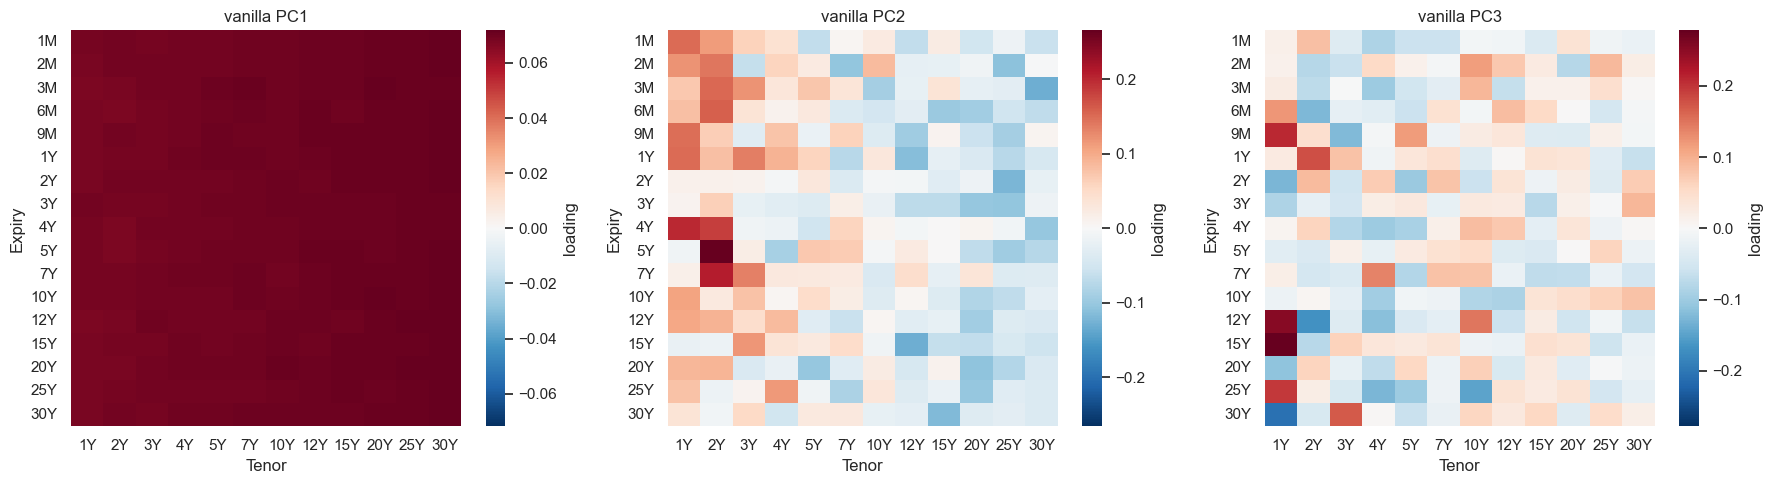

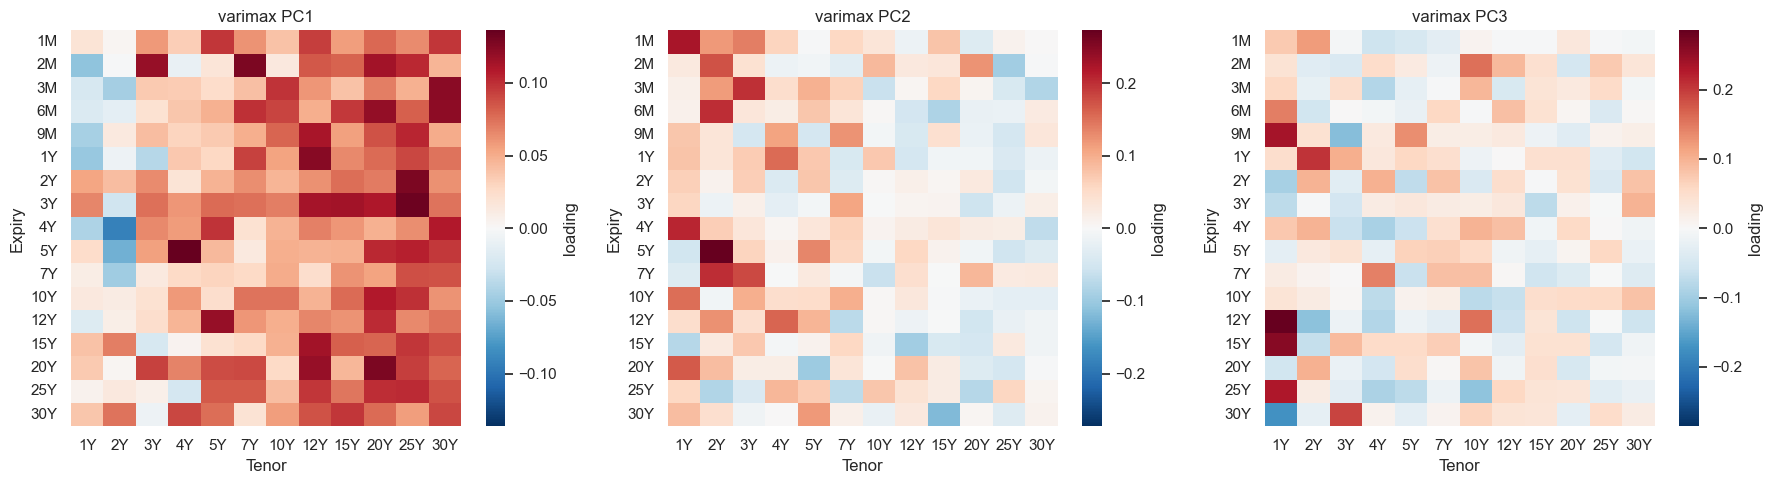

In [2]:
l_rot = varimax(l_van)
s_rot = rotate_scores(s_van, l_van, l_rot)

gini_before = loading_sparsity(l_van)
gini_after  = loading_sparsity(l_rot)
print(pd.concat({"vanilla": gini_before, "varimax": gini_after}, axis=1).round(3))

plot_loadings(l_van, ["PC1", "PC2", "PC3"], "vanilla")
plot_loadings(l_rot, ["PC1", "PC2", "PC3"], "varimax")

## 2. Hierarchical PCA

Pull out per-date cube mean (the cross-sectional average across all
`(expiry, tenor)` cells) as an explicit **level** factor, then run PCA
on the residual. PC1 of the residual is no longer the level mode, so
slope / curvature / region-specific structure shows up immediately.

Reconstruction count `K` is **total factors** = `1 (level) + n_pcs`.

residual-PCA explained: [0.069, 0.012, 0.012, 0.011, 0.011]


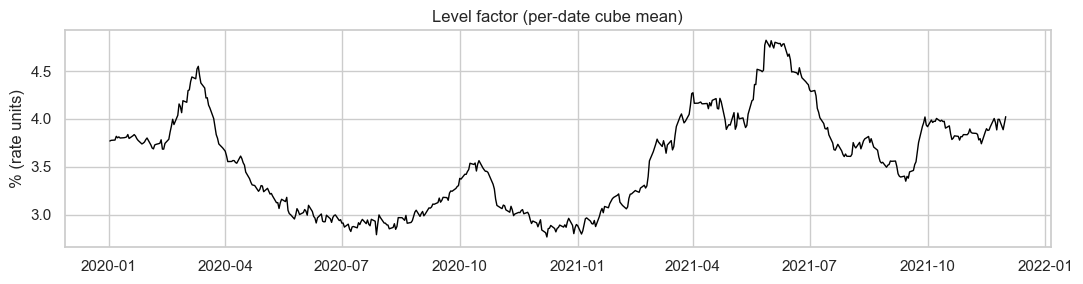

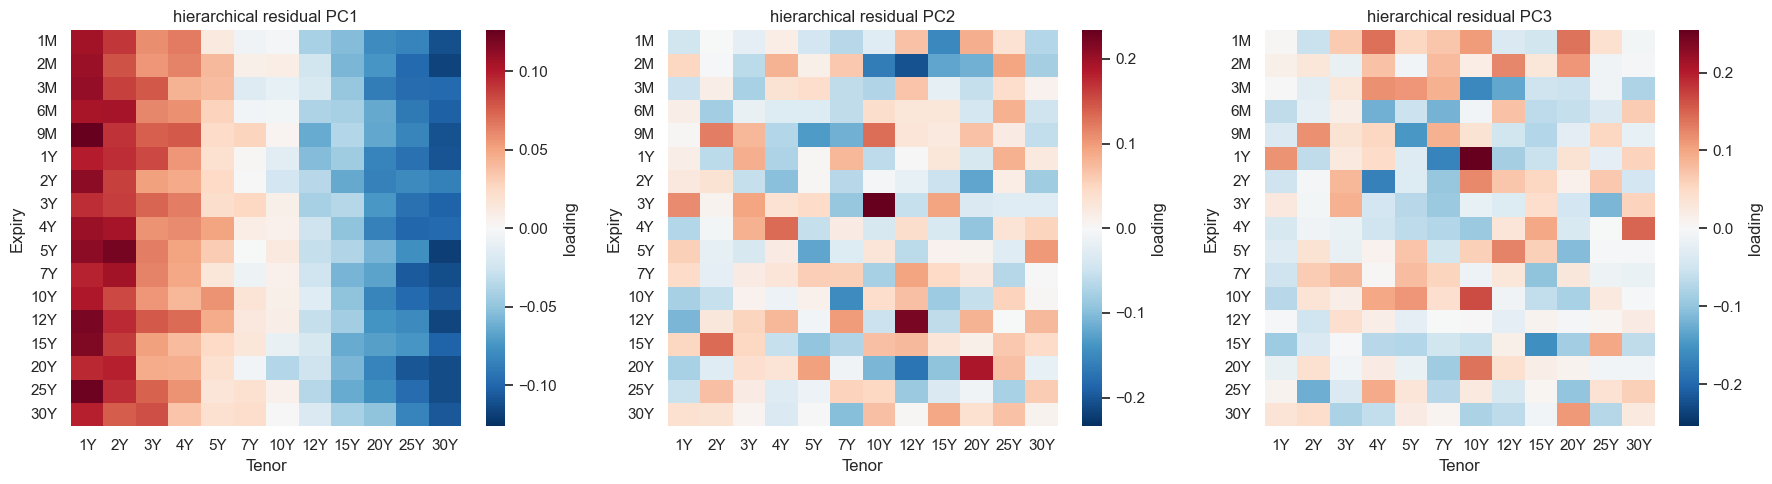

In [3]:
level, resid_h, s_h, l_h, e_h = hierarchical_pca(rate, n_components=5)
print("residual-PCA explained:", e_h.round(3).tolist())

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(level.index, level.values, color="black", linewidth=1.0)
ax.set_title("Level factor (per-date cube mean)")
ax.set_ylabel("% (rate units)")
plt.tight_layout(); plt.show()

plot_loadings(l_h, ["PC1", "PC2", "PC3"], "hierarchical residual")

## 3. Pre-defined bucket factors + residual PCA

Define a handful of hedge-mappable regions of the cube, regress them
out of every cell jointly (OLS with intercept), and PCA the residual.
The residual PCs describe **what the bucket factors fail to capture**
— smaller, more localised modes that a trader can either accept as
basis risk or hedge with a satellite instrument.

Default buckets are illustrative — `factors.default_buckets()` returns
a starter dict; replace with the desk's actual hedge axes.

buckets: {'short_level': 12, 'long_level': 42, 'slope_2s10s': 34, 'belly': 12}


residual-PCA explained: [0.015, 0.013, 0.012, 0.012, 0.012]


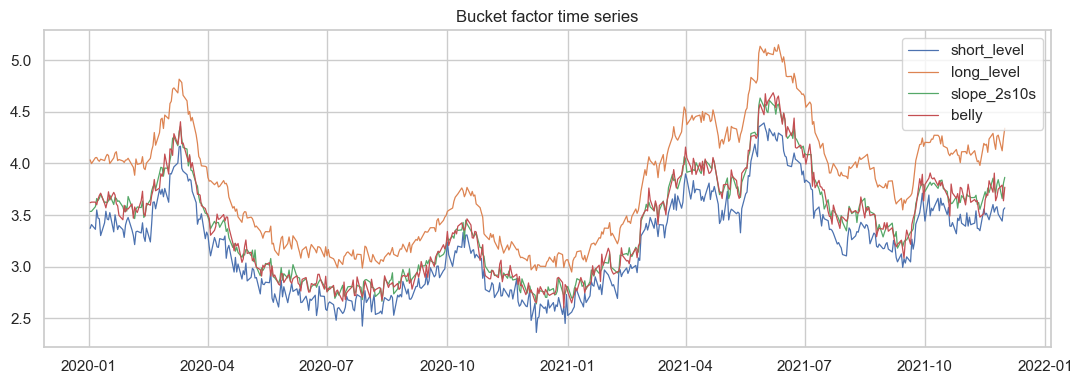

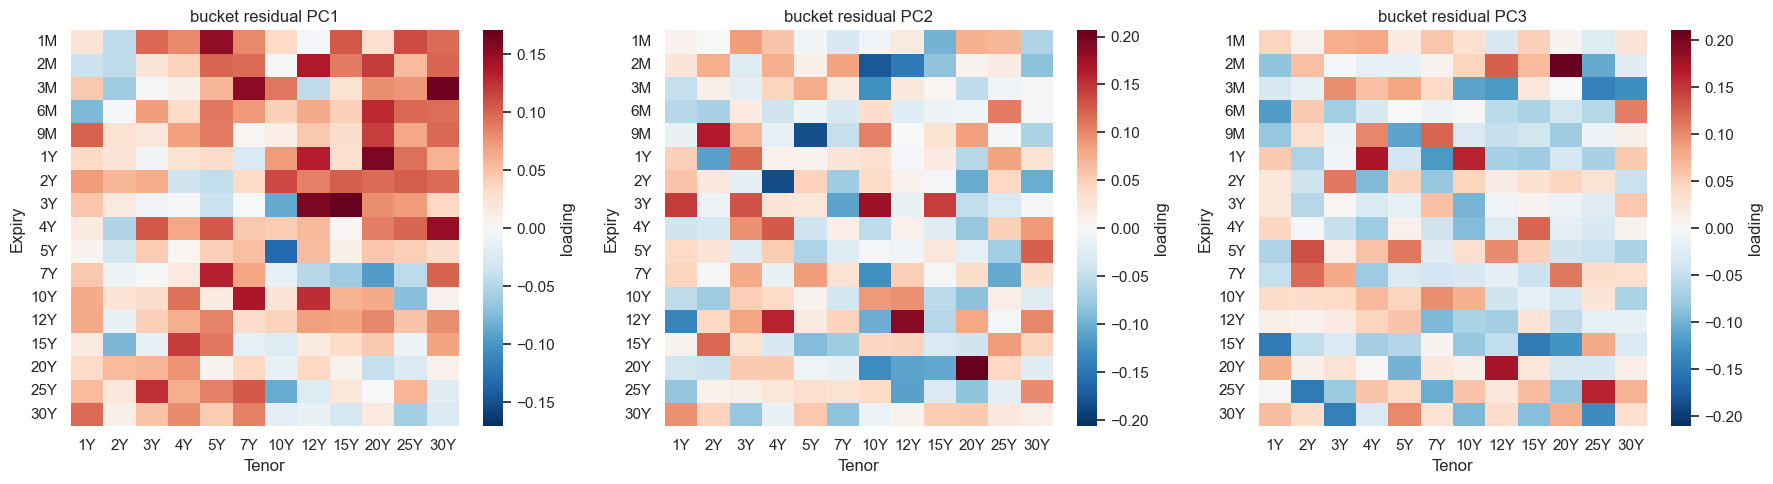

In [4]:
buckets = default_buckets()
print("buckets:", {k: len(v) for k, v in buckets.items()})

bf, resid_b, s_b, l_b, e_b = bucket_residual_pca(rate, buckets, n_components=5)
print("residual-PCA explained:", e_b.round(3).tolist())

fig, ax = plt.subplots(figsize=(11, 4))
for col in bf.columns:
    ax.plot(bf.index, bf[col], label=col, linewidth=0.9)
ax.legend(loc="upper right")
ax.set_title("Bucket factor time series")
plt.tight_layout(); plt.show()

plot_loadings(l_b, ["PC1", "PC2", "PC3"], "bucket residual")

## 4. Joint rate-vol structure (CCA + lagged correlation)

Do rate and vol PCs share latent drivers? Vanilla cross-correlation
of PC pairs gives a hint (we saw rate-PC1 ↔ vol-PC1 in `pca.ipynb`),
but **CCA** answers it directly: find the linear combination of vol
PCs most correlated with a linear combination of rate PCs.

Then check `lagged_corr` to see if either side leads — relevant for
anticipating vol moves from rate moves (or vice versa).

canonical correlations:
CC1    0.883
CC2    0.230
CC3    0.088
Name: canonical_corr, dtype: float64


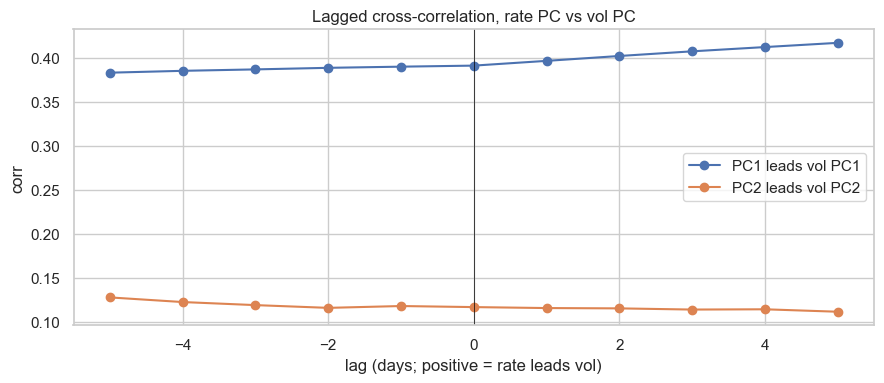

In [5]:
s_vol, l_vol, e_vol = run_pca(vol, n_components=5)

rate_canon, vol_canon, canon_corr = cross_surface_cca(s_van, s_vol, n_components=3)
print("canonical correlations:")
print(canon_corr.round(3))

lc = pd.DataFrame({
    "PC1 leads vol PC1": lagged_corr(s_van["PC1"], s_vol["PC1"], range(-5, 6)),
    "PC2 leads vol PC2": lagged_corr(s_van["PC2"], s_vol["PC2"], range(-5, 6)),
})
fig, ax = plt.subplots(figsize=(9, 4))
for col in lc.columns:
    ax.plot(lc.index, lc[col], marker="o", label=col)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("lag (days; positive = rate leads vol)")
ax.set_ylabel("corr")
ax.set_title("Lagged cross-correlation, rate PC vs vol PC")
ax.legend(); plt.tight_layout(); plt.show()

## 5. Comparison metrics — one row per method

All four metrics from the README in a single table:

* `var_at_K`           — cumulative explained variance at K factors
  (note: for hierarchical / bucket the level / bucket fits are *not*
  reflected here — they only count the residual PCs).
* `resid_at_K`         — fraction of original-surface variance left
  unexplained by K-factor reconstruction (the hedge-replication proxy).
  Directly comparable across methods because every reconstruction is
  in raw surface units. **K means total factors** — for hierarchical
  it includes the level; for bucket_residual it includes the buckets.
* `loading_gini_mean`  — average Gini across PC loadings (1 = sparse).
* `stability_mean`     — average rolling-window cosine similarity of
  loadings vs the full-sample loadings (1 = perfectly stable).

In [6]:
# Per-method reconstruction recipes. K = total factors.
n_buckets = bf.shape[1]

repl_van = {k: replication_residual(rate, reconstruct(s_van, l_van, rate, k))
            for k in (1, 3, 5)}
repl_rot = {k: replication_residual(rate, reconstruct(s_rot, l_rot, rate, k))
            for k in (1, 3, 5)}
repl_h   = {k: replication_residual(rate,
                reconstruct_hierarchical(level, s_h, l_h, resid_h, n_pcs=k - 1))
            for k in (1, 3, 5)}
repl_b_k = (n_buckets, n_buckets + 2, n_buckets + 4)
repl_b   = {k: replication_residual(rate,
                reconstruct_bucket_residual(rate, resid_b, s_b, l_b,
                                            n_pcs=k - n_buckets))
            for k in repl_b_k}

rows = [
    metrics_table("vanilla",         rate, s_van, l_van, e_van, replication=repl_van),
    metrics_table("varimax",         rate, s_rot, l_rot, e_van, replication=repl_rot),
    metrics_table("hierarchical",    rate, s_h,   l_h,   e_h,   replication=repl_h),
    metrics_table("bucket_residual", rate, s_b,   l_b,   e_b,   replication=repl_b,
                  k_grid=repl_b_k),
]
summary = pd.concat(rows, ignore_index=True)
summary.round(3)

,method,loading_gini_mean,stability_mean,var_at_1,resid_at_1,var_at_3,resid_at_3,var_at_5,resid_at_5,var_at_4,resid_at_4,resid_at_6,resid_at_8
0,vanilla,0.354,0.653,0.865,0.131,0.869,0.128,0.872,0.125,NaN,NaN,NaN,NaN
1,varimax,0.426,0.653,0.865,0.399,0.869,0.278,0.872,0.125,NaN,NaN,NaN,NaN
2,hierarchical,0.398,0.653,0.069,0.140,0.093,0.128,0.116,0.125,NaN,NaN,NaN,NaN
3,bucket_residual,0.394,0.653,NaN,NaN,NaN,NaN,NaN,NaN,0.053,0.129,0.125,0.122


## Notes for production hand-off

* Swap `data/mock/*.pkl` for real-data pkls of the same shape — the
  notebook needs no other change.
* `default_buckets()` is illustrative. The bucket dict is the only
  hand-tuned input: edit it (or build it from the desk's hedge
  inventory) before reading anything into Section 3.
* Number-of-factors choice is method-dependent. Use `var_at_K` and
  `resid_at_K` jointly: stop adding factors when `resid_at_K` plateaus.